# Dataset visualization — `subliminal_isomorphism`

Inspect the `(phi, psi)` permutation pairs that the model is trained / validated on.

- `train` (`dataset.pt`): the fixed memorization set.
- `val1` (`val1.pt`): an iid-fresh sample. By chance, some pairs may coincide with `train`.
- `val2` (`val2.pt`): rejection-sampled to guarantee disjoint from `train`.

Goals: (1) see a few examples; (2) verify `val2 ∩ train = ∅`; (3) characterize coverage / duplication / per-coordinate marginals.

In [1]:
import sys, os
from pathlib import Path

# Notebook lives in subliminal_isomorphism/data/ ; project root is the parent.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / 'data'

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

import config
print(f'N = {config.N}   |   |S_N| = {math.factorial(config.N)}')
print(f'DATASET_SIZE = {config.DATASET_SIZE}   VAL_SIZE = {config.VAL_SIZE}')
print(f'VOCAB = {config.VOCAB}')
print(f'paths: {DATA_DIR}')

N = 4   |   |S_N| = 24
DATASET_SIZE = 100   VAL_SIZE = 50
VOCAB = 4
paths: /home/akash10/Documents/SelfProving/subliminal_isomorphism/data


In [2]:
def load(path):
    d = torch.load(path, weights_only=True)
    return d['phi'], d['psi']

train_phi, train_psi = load(DATA_DIR / 'dataset.pt')
val1_phi,  val1_psi  = load(DATA_DIR / 'val1.pt')
val2_phi,  val2_psi  = load(DATA_DIR / 'val2.pt')

for name, phi, psi in [('train', train_phi, train_psi),
                       ('val1',  val1_phi,  val1_psi),
                       ('val2',  val2_phi,  val2_psi)]:
    print(f'{name:6s}   phi {tuple(phi.shape)}   psi {tuple(psi.shape)}   dtype={phi.dtype}')

train    phi (100, 4)   psi (100, 4)   dtype=torch.int64
val1     phi (50, 4)   psi (50, 4)   dtype=torch.int64
val2     phi (50, 4)   psi (50, 4)   dtype=torch.int64


## A few examples from each split

In [3]:
def show_examples(name, phi, psi, k=8):
    psi_inv = torch.argsort(psi, dim=1)
    phi_psi_inv = phi.gather(1, psi_inv)
    w = 2 * config.N + 3
    print(f'=== {name} (first {k}) ===')
    print(f'  {"idx":>3}  {"phi":<{w}}  {"psi":<{w}}  {"psi_inv":<{w}}  {"phi∘psi^-1":<{w}}')
    for i in range(min(k, phi.shape[0])):
        print(f'  {i:>3}  {str(phi[i].tolist()):<{w}}  '
              f'{str(psi[i].tolist()):<{w}}  '
              f'{str(psi_inv[i].tolist()):<{w}}  '
              f'{str(phi_psi_inv[i].tolist()):<{w}}')
    print()

show_examples('train', train_phi, train_psi)
show_examples('val1',  val1_phi,  val1_psi)
show_examples('val2',  val2_phi,  val2_psi)

=== train (first 8) ===
  idx  phi          psi          psi_inv      phi∘psi^-1 
    0  [0, 1, 3, 2]  [1, 3, 0, 2]  [2, 0, 3, 1]  [3, 0, 2, 1]
    1  [0, 2, 3, 1]  [0, 1, 3, 2]  [0, 1, 3, 2]  [0, 2, 1, 3]
    2  [3, 2, 0, 1]  [3, 1, 0, 2]  [2, 1, 3, 0]  [0, 2, 1, 3]
    3  [3, 0, 2, 1]  [1, 3, 2, 0]  [3, 0, 2, 1]  [1, 3, 2, 0]
    4  [0, 1, 2, 3]  [0, 2, 3, 1]  [0, 3, 1, 2]  [0, 3, 1, 2]
    5  [0, 1, 2, 3]  [3, 0, 1, 2]  [1, 2, 3, 0]  [1, 2, 3, 0]
    6  [2, 1, 0, 3]  [1, 3, 0, 2]  [2, 0, 3, 1]  [0, 2, 3, 1]
    7  [3, 0, 2, 1]  [3, 1, 2, 0]  [3, 1, 2, 0]  [1, 0, 2, 3]

=== val1 (first 8) ===
  idx  phi          psi          psi_inv      phi∘psi^-1 
    0  [1, 3, 2, 0]  [3, 0, 2, 1]  [1, 3, 2, 0]  [3, 0, 2, 1]
    1  [0, 2, 3, 1]  [1, 2, 0, 3]  [2, 0, 1, 3]  [3, 0, 2, 1]
    2  [3, 0, 1, 2]  [2, 1, 3, 0]  [3, 1, 0, 2]  [2, 0, 3, 1]
    3  [0, 3, 1, 2]  [2, 0, 1, 3]  [1, 2, 0, 3]  [3, 1, 0, 2]
    4  [0, 3, 1, 2]  [1, 0, 3, 2]  [1, 0, 3, 2]  [3, 0, 2, 1]
    5  [0, 1, 3, 2]  [0, 1, 2,

## Verify `val2 ∩ train = ∅`

We compare the full `(phi, psi)` pair as a tuple — the same equality the dataset generator uses for rejection. We also report `val1` overlap (which is *not* enforced disjoint, so we expect some collisions for small `n`).

In [4]:
def to_pair_set(phi, psi):
    return {(tuple(p.tolist()), tuple(q.tolist())) for p, q in zip(phi, psi)}

train_pairs = to_pair_set(train_phi, train_psi)
val1_pairs  = to_pair_set(val1_phi,  val1_psi)
val2_pairs  = to_pair_set(val2_phi,  val2_psi)

v1_in_train = val1_pairs & train_pairs
v2_in_train = val2_pairs & train_pairs

print(f'|train| (unique pairs) = {len(train_pairs)} / {train_phi.shape[0]}')
print(f'|val1|  (unique pairs) = {len(val1_pairs)}  / {val1_phi.shape[0]}')
print(f'|val2|  (unique pairs) = {len(val2_pairs)}  / {val2_phi.shape[0]}')
print()
print(f'val1 ∩ train: {len(v1_in_train)} pairs   (not constrained to be empty)')
print(f'val2 ∩ train: {len(v2_in_train)} pairs   (should be 0)')

assert len(v2_in_train) == 0, f'val2 leaked: {len(v2_in_train)} pairs are in train!'
print('\nval2 is disjoint from train. ✓')
if v1_in_train:
    print('\nval1 collisions with train (first 5):')
    for p, q in list(v1_in_train)[:5]:
        print(f'  phi={list(p)}  psi={list(q)}')

|train| (unique pairs) = 91 / 100
|val1|  (unique pairs) = 47  / 50
|val2|  (unique pairs) = 43  / 50

val1 ∩ train: 7 pairs   (not constrained to be empty)
val2 ∩ train: 0 pairs   (should be 0)

val2 is disjoint from train. ✓

val1 collisions with train (first 5):
  phi=[3, 0, 1, 2]  psi=[0, 2, 1, 3]
  phi=[0, 2, 3, 1]  psi=[1, 2, 0, 3]
  phi=[0, 3, 1, 2]  psi=[2, 0, 1, 3]
  phi=[2, 3, 0, 1]  psi=[3, 2, 0, 1]
  phi=[3, 0, 1, 2]  psi=[1, 2, 3, 0]


## Coverage of $S_n$ in train

How many of the `n!` permutations appear at least once as `phi` (or as `psi`) in the training set?

For small `n` (e.g. `n=4`, `|S_4|=24`), with `DATASET_SIZE=100` we expect to cover all of $S_n$ with high probability — meaning the test set in `cost.py` (which enumerates all of $S_n$) is essentially identical to the training set.

In [5]:
n_fact = math.factorial(config.N)

train_phi_set = {tuple(p.tolist()) for p in train_phi}
train_psi_set = {tuple(q.tolist()) for q in train_psi}

phi_counts = Counter(tuple(p.tolist()) for p in train_phi)
psi_counts = Counter(tuple(q.tolist()) for q in train_psi)

print(f'Unique phi in train:   {len(train_phi_set)} / {n_fact}   ({100*len(train_phi_set)/n_fact:.1f}% of S_n)')
print(f'Unique psi in train:   {len(train_psi_set)} / {n_fact}   ({100*len(train_psi_set)/n_fact:.1f}% of S_n)')
print(f'Unique (phi,psi) pairs: {len(train_pairs)} / {len(train_phi)} (so {len(train_phi) - len(train_pairs)} duplicate pairs)')
print()
print(f'phi-multiplicity (how many times each unique phi appears):')
mult = Counter(phi_counts.values())
for k in sorted(mult):
    print(f'  {k:>2}× : {mult[k]} unique phis')
print(f'  mean = {np.mean(list(phi_counts.values())):.2f}, max = {max(phi_counts.values())}, min = {min(phi_counts.values())}')

Unique phi in train:   24 / 24   (100.0% of S_n)
Unique psi in train:   24 / 24   (100.0% of S_n)
Unique (phi,psi) pairs: 91 / 100 (so 9 duplicate pairs)

phi-multiplicity (how many times each unique phi appears):
   1× : 1 unique phis
   2× : 2 unique phis
   3× : 5 unique phis
   4× : 3 unique phis
   5× : 10 unique phis
   6× : 3 unique phis
  mean = 4.17, max = 6, min = 1


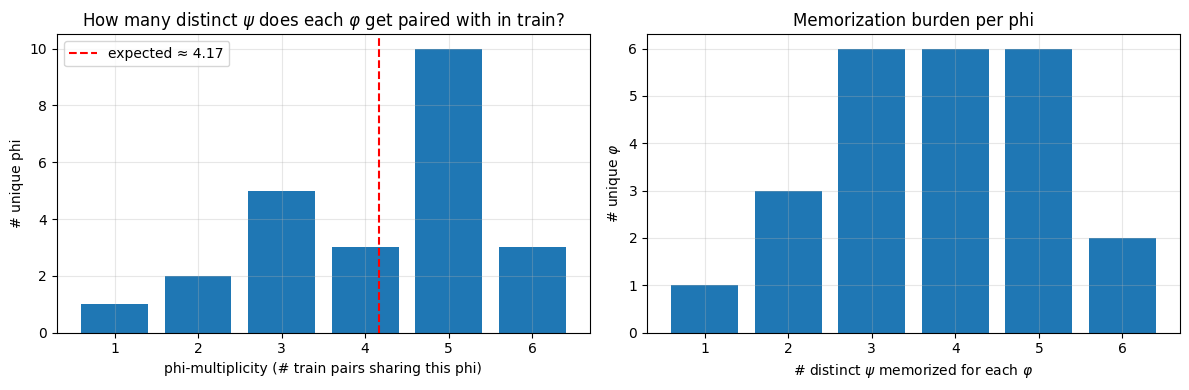

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(*zip(*sorted(Counter(phi_counts.values()).items())))
ax[0].set_xlabel('phi-multiplicity (# train pairs sharing this phi)')
ax[0].set_ylabel('# unique phi')
ax[0].set_title(r'How many distinct $\psi$ does each $\varphi$ get paired with in train?')
ax[0].axvline(config.DATASET_SIZE / n_fact, ls='--', color='red',
              label=f'expected ≈ {config.DATASET_SIZE/n_fact:.2f}')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Distinct psi per phi (relevant: this is the # of memorized targets per phi).
phi_to_psis = {}
for p, q in zip(train_phi, train_psi):
    phi_to_psis.setdefault(tuple(p.tolist()), set()).add(tuple(q.tolist()))
distinct_psi_per_phi = [len(s) for s in phi_to_psis.values()]

ax[1].bar(*zip(*sorted(Counter(distinct_psi_per_phi).items())))
ax[1].set_xlabel(r'# distinct $\psi$ memorized for each $\varphi$')
ax[1].set_ylabel(r'# unique $\varphi$')
ax[1].set_title('Memorization burden per phi')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Per-coordinate marginal of `psi` over the training set

If $\psi$ is sampled uniformly from $S_n$, then for every position $i$ and value $v$, $P[\psi(i)=v] = 1/n$. The plot below shows the empirical fraction over the training set; deviations from $1/n$ are pure **sampling noise** (~$\sqrt{(1/n)(1-1/n)/\text{DATASET\_SIZE}}$). This is the population baseline that a perfectly trained model should match.

1/n target = 0.2500,   1-sigma noise floor = 0.0433


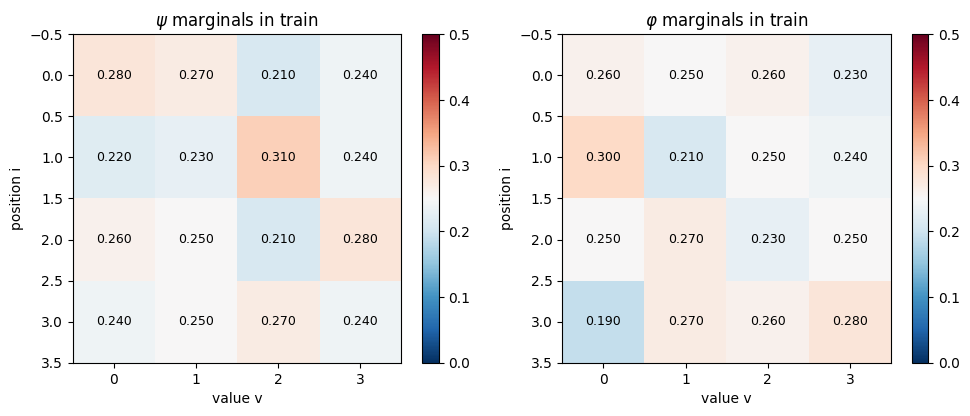

In [7]:
def marginal_matrix(perms, n):
    M = np.zeros((n, n))
    for p in perms:
        for i, v in enumerate(p.tolist()):
            M[i, v] += 1
    return M / perms.shape[0]

n = config.N
M_train_psi = marginal_matrix(train_psi, n)
M_train_phi = marginal_matrix(train_phi, n)

noise = math.sqrt((1/n) * (1 - 1/n) / config.DATASET_SIZE)
print(f'1/n target = {1/n:.4f},   1-sigma noise floor = {noise:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, M, title in [(ax[0], M_train_psi, r'$\psi$ marginals in train'),
                    (ax[1], M_train_phi, r'$\varphi$ marginals in train')]:
    im = a.imshow(M, vmin=0, vmax=2/n, cmap='RdBu_r')
    a.set_title(title)
    a.set_xlabel('value v'); a.set_ylabel('position i')
    for i in range(n):
        for v in range(n):
            a.text(v, i, f'{M[i,v]:.3f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=a)
plt.tight_layout(); plt.show()

## Independence check: is $\psi \perp \varphi$ in training?

By construction (`generate_dataset.py:18-20`), $\varphi, \psi$ are sampled independently. As a sanity check, we look at the conditional marginal $\hat P[\psi(i) = v \mid \varphi(0) = b]$ for each $b$. If $\psi \perp \varphi$, all rows should look the same (up to sampling noise). Anything systematic here would mean the data itself encodes a leak — which would invalidate later experiments.

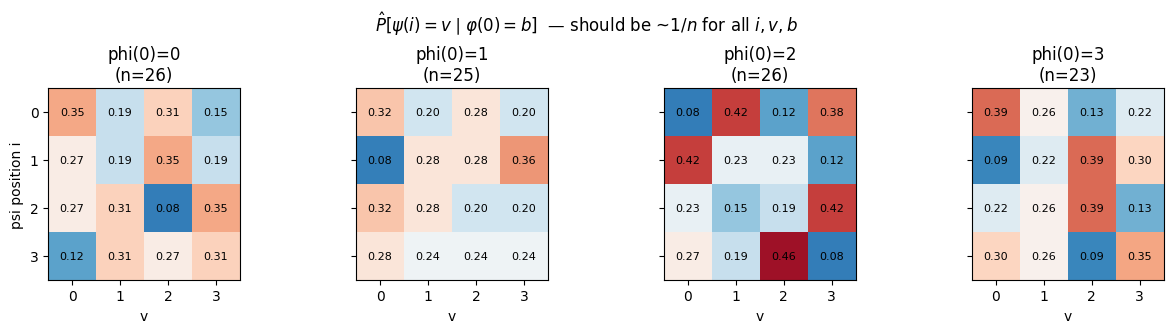

Max |M - 1/n| per conditional (vs. noise floor):
  phi(0)=0: max-dev=0.173   (noise floor for this slice = 0.085, n=26)
  phi(0)=1: max-dev=0.170   (noise floor for this slice = 0.087, n=25)
  phi(0)=2: max-dev=0.212   (noise floor for this slice = 0.085, n=26)
  phi(0)=3: max-dev=0.163   (noise floor for this slice = 0.090, n=23)


In [8]:
n = config.N
fig, axes = plt.subplots(1, n, figsize=(3.2*n, 3.2), sharey=True)
for b in range(n):
    mask = (train_phi[:, 0] == b)
    if mask.sum() == 0:
        axes[b].set_title(f'phi(0)={b}\n(no samples)')
        continue
    sub = train_psi[mask]
    M = marginal_matrix(sub, n)
    im = axes[b].imshow(M, vmin=0, vmax=2/n, cmap='RdBu_r')
    axes[b].set_title(f'phi(0)={b}\n(n={int(mask.sum())})')
    axes[b].set_xlabel('v'); 
    if b == 0: axes[b].set_ylabel('psi position i')
    for i in range(n):
        for v in range(n):
            axes[b].text(v, i, f'{M[i,v]:.2f}', ha='center', va='center', fontsize=8)
plt.suptitle(r'$\hat P[\psi(i)=v \mid \varphi(0)=b]$  — should be ~$1/n$ for all $i,v,b$')
plt.tight_layout(); plt.show()

# Quantitative: max deviation per conditional matrix.
print('Max |M - 1/n| per conditional (vs. noise floor):')
for b in range(n):
    mask = (train_phi[:, 0] == b)
    if mask.sum() == 0:
        continue
    M = marginal_matrix(train_psi[mask], n)
    noise_b = math.sqrt((1/n)*(1-1/n) / int(mask.sum()))
    print(f'  phi(0)={b}: max-dev={np.abs(M-1/n).max():.3f}   '
          f'(noise floor for this slice = {noise_b:.3f}, n={int(mask.sum())})')

## Deterministic auxiliary blocks: `psi_inv` and `phi ∘ psi^{-1}`

The training sequence has four blocks:
$$[\;\varphi \mid \psi \mid \psi^{-1} \mid \varphi \circ \psi^{-1}\;]$$

The last two are deterministic functions of `(phi, psi)`. Sanity-check:

- `psi[psi_inv] == identity` (i.e. `psi_inv = argsort(psi)` is the actual inverse).
- `phi_psi_inv[i] == phi[psi_inv[i]]` (composition).
- Both `psi_inv` and `phi_psi_inv` are valid permutations.

In [9]:
def is_perm(x, n):
    return sorted(x.tolist()) == list(range(n))

def check(name, phi, psi):
    n = psi.shape[1]
    psi_inv = torch.argsort(psi, dim=1)
    phi_psi_inv = phi.gather(1, psi_inv)

    # psi composed with psi_inv == identity
    composed = psi.gather(1, psi_inv)
    expected = torch.arange(n).unsqueeze(0).expand_as(composed)
    ok_compose = bool((composed == expected).all().item())

    # phi_psi_inv[i] == phi[psi_inv[i]] (definition)
    manual = torch.stack([phi[i][psi_inv[i]] for i in range(phi.shape[0])])
    ok_phi_psi_inv = bool((phi_psi_inv == manual).all().item())

    ok_psi_inv_perm     = all(is_perm(psi_inv[i],     n) for i in range(phi.shape[0]))
    ok_phi_psi_inv_perm = all(is_perm(phi_psi_inv[i], n) for i in range(phi.shape[0]))

    print(f'{name:6s}  '
          f'psi[psi_inv]==id:{ok_compose}   '
          f'phi∘psi^-1==phi[psi_inv]:{ok_phi_psi_inv}   '
          f'psi_inv perm:{ok_psi_inv_perm}   '
          f'phi∘psi^-1 perm:{ok_phi_psi_inv_perm}')

check('train', train_phi, train_psi)
check('val1',  val1_phi,  val1_psi)
check('val2',  val2_phi,  val2_psi)

train   psi[psi_inv]==id:True   phi∘psi^-1==phi[psi_inv]:True   psi_inv perm:True   phi∘psi^-1 perm:True
val1    psi[psi_inv]==id:True   phi∘psi^-1==phi[psi_inv]:True   psi_inv perm:True   phi∘psi^-1 perm:True
val2    psi[psi_inv]==id:True   phi∘psi^-1==phi[psi_inv]:True   psi_inv perm:True   phi∘psi^-1 perm:True


## `build_sequence` round-trip

Verify that the model-input sequences produced by `build_sequence` match the layout declared in `config.py` (so the slices `PHI`, `PSI`, `PSI_INV`, `PHI_PSI_INV` actually pick out the right blocks).

In [10]:
from generate_dataset import build_sequence

seq = build_sequence(train_phi, train_psi)
print(f'sequence shape: {tuple(seq.shape)}   (expected (B, {config.SEQ_LEN}))')
assert seq.shape[1] == config.SEQ_LEN, 'SEQ_LEN mismatch — config and build_sequence disagree!'

psi_inv_expected     = torch.argsort(train_psi, dim=1)
phi_psi_inv_expected = train_phi.gather(1, psi_inv_expected)

checks = [
    ('PHI block         ', seq[:, config.PHI],         train_phi),
    ('PSI block         ', seq[:, config.PSI],         train_psi),
    ('PSI_INV block     ', seq[:, config.PSI_INV],     psi_inv_expected),
    ('PHI_PSI_INV block ', seq[:, config.PHI_PSI_INV], phi_psi_inv_expected),
]
for label, got, want in checks:
    print(f'  {label}: matches = {bool((got == want).all().item())}')

# Also: every block at every row should be a permutation of 0..N-1
for label, blk in [('PHI', config.PHI), ('PSI', config.PSI),
                   ('PSI_INV', config.PSI_INV), ('PHI_PSI_INV', config.PHI_PSI_INV)]:
    rows = seq[:, blk]
    all_perms = all(sorted(rows[i].tolist()) == list(range(config.N))
                    for i in range(rows.shape[0]))
    print(f'  {label:<12} every row is a permutation: {all_perms}')

sequence shape: (100, 16)   (expected (B, 16))
  PHI block         : matches = True
  PSI block         : matches = True
  PSI_INV block     : matches = True
  PHI_PSI_INV block : matches = True
  PHI          every row is a permutation: True
  PSI          every row is a permutation: True
  PSI_INV      every row is a permutation: True
  PHI_PSI_INV  every row is a permutation: True


## Summary table

In [11]:
rows = []
for name, phi, psi, pairs in [('train', train_phi, train_psi, train_pairs),
                              ('val1',  val1_phi,  val1_psi,  val1_pairs),
                              ('val2',  val2_phi,  val2_psi,  val2_pairs)]:
    n_phi_unique = len({tuple(p.tolist()) for p in phi})
    n_psi_unique = len({tuple(q.tolist()) for q in psi})
    rows.append((name, len(phi), len(pairs), n_phi_unique, n_psi_unique,
                 len(pairs & train_pairs)))

print(f'{"split":<6} | {"size":>5} | {"unique pairs":>13} | {"unique phi":>10} | {"unique psi":>10} | {"∩ train":>8}')
print('-' * 72)
for r in rows:
    print(f'{r[0]:<6} | {r[1]:>5} | {r[2]:>13} | {r[3]:>10} | {r[4]:>10} | {r[5]:>8}')

split  |  size |  unique pairs | unique phi | unique psi |  ∩ train
------------------------------------------------------------------------
train  |   100 |            91 |         24 |         24 |       91
val1   |    50 |            47 |         24 |         23 |        7
val2   |    50 |            43 |         21 |         22 |        0
